# Savegame Analysis Workbench

Build or refresh the raw savegame parquet dataset first:

```bash
uv run ppc savegame-notebooks build
```

All analysis below uses Polars lazy scans over `graphs/dataset`. Change selector variables in the setup cell, then rerun the relevant section.

In [1]:
from eu5gameparser.savegame import notebook_workbench as wb

DATA_ROOT = None       # None means graphs/dataset under the constructor repo
PLAYTHROUGH = None     # None means latest playthrough
START_DATE = None      # example: 13370101
END_DATE = None        # example: 14000101
SNAPSHOT_DATE = None   # None means latest selected snapshot

GOOD_SEARCH = "victuals"
MARKET_SEARCH = None   # None means all markets; set to e.g. "london" for market drilldowns
BUILDING_SEARCH = "cookery"
PM_DRILLDOWN_SEARCH = None  # set to e.g. "packing" only for PM flow/value drilldowns
COUNTRY_SEARCH = "england"

GROUP_BY = "region"
BUILDING_SCOPE = "macro_region"
FLOW_GROUP_BY = ("flow_table", "market")
CONSUMPTION_GROUP_BY = "bucket"
IMBALANCE_SORT = "mean_flow"  # mean_flow, total_flow, mean_market_cap, total_market_cap
AGG = "sum"           # sum, mean, median over raw selected rows
TOP_N = 25
BUCKET_YEARS = 25
START_YEAR = 1337
POPULATION_METRIC = "total_population"
FOOD_RANK_BY = "food_fill_ratio"
BUILDING_METRIC = "level"

workbench = wb.open_workbench(wb.WorkbenchConfig.from_mapping(globals()))
ds = workbench.dataset
snapshots = workbench.snapshots


## Search And Snapshot Context

In [2]:
workbench.print_selection()
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary = workbench.preview()
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary


repo: C:\Development\ProsperOrPerishConstructor
data: C:\Development\ProsperOrPerishConstructor\graphs\dataset
data mode: raw
playthrough: 7b8d236a_4e36_4d0e_af0d_fe3720af118d
good: Victuals (victuals)
market search: all markets
building search: cookery
pm drilldown search: none


(shape: (1, 4)
 ┌───────────┬──────────┬────────────────┬────────────┐
 │ good_code ┆ good_id  ┆ goods_category ┆ good_label │
 │ ---       ┆ ---      ┆ ---            ┆ ---        │
 │ u32       ┆ str      ┆ str            ┆ str        │
 ╞═══════════╪══════════╪════════════════╪════════════╡
 │ 69        ┆ victuals ┆ produced       ┆ Victuals   │
 └───────────┴──────────┴────────────────┴────────────┘,
 shape: (25, 5)
 ┌─────────────┬───────────┬────────────────────┬────────────────────┬────────────────┐
 │ market_code ┆ market_id ┆ market_center_slug ┆ center_location_id ┆ market_label   │
 │ ---         ┆ ---       ┆ ---                ┆ ---                ┆ ---            │
 │ u32         ┆ i64       ┆ str                ┆ i64                ┆ str            │
 ╞═════════════╪═══════════╪════════════════════╪════════════════════╪════════════════╡
 │ 0           ┆ 0         ┆ lubeck             ┆ 846                ┆ Lubeck         │
 │ 1           ┆ 1         ┆ riga               

## Population / Locations Over Time

In [3]:
population = workbench.population()
population_latest = population.latest
population_delta = population.delta
population_ts = population.time_series
population_ts_top = population.top_time_series
population_global = population.global_time_series
population_latest, population_delta, population_global


(shape: (25, 2)
 ┌──────────────────────┬──────────────────┐
 │ region_label         ┆ total_population │
 │ ---                  ┆ ---              │
 │ str                  ┆ f32              │
 ╞══════════════════════╪══════════════════╡
 │ Hindustan Region     ┆ 31610.580078     │
 │ Indochina Region     ┆ 25780.736328     │
 │ Bengal Region        ┆ 25076.650391     │
 │ Deccan Region        ┆ 24862.464844     │
 │ East China Region    ┆ 20504.916016     │
 │ Western India Region ┆ 18883.097656     │
 │ France Region        ┆ 18842.828125     │
 │ Indonesia Region     ┆ 16497.083984     │
 │ North German Region  ┆ 14824.836914     │
 │ Italy Region         ┆ 14102.674805     │
 │ Japan Region         ┆ 14059.291992     │
 │ South China Region   ┆ 12489.848633     │
 │ Central India Region ┆ 12483.900391     │
 │ South German Region  ┆ 11750.347656     │
 │ Iberia Region        ┆ 10657.603516     │
 │ Persia Region        ┆ 9965.350586      │
 │ Maghreb Region       ┆ 9064.279297  

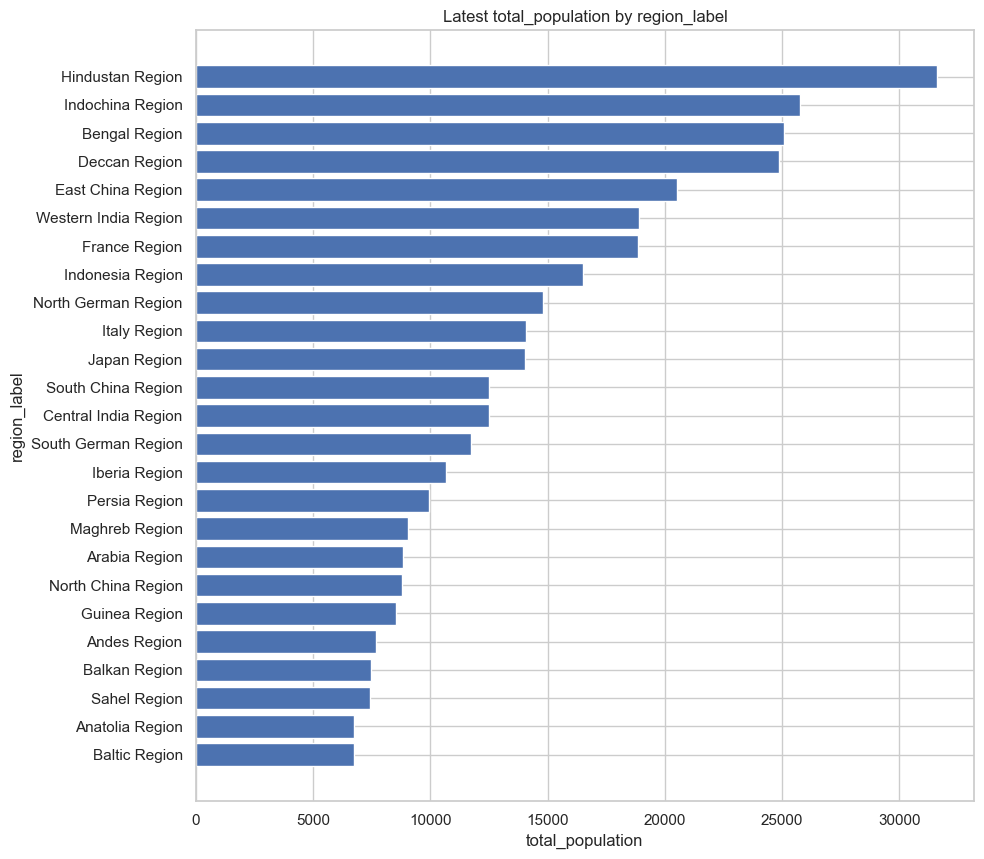

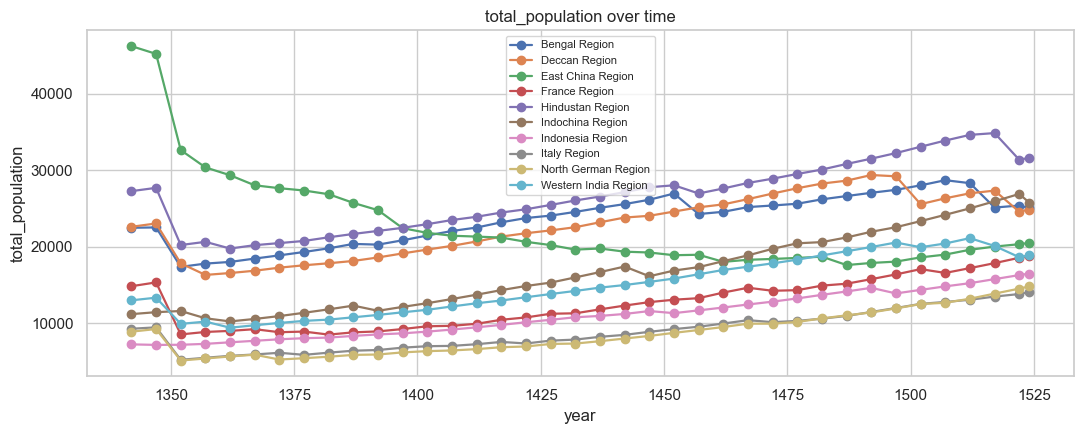

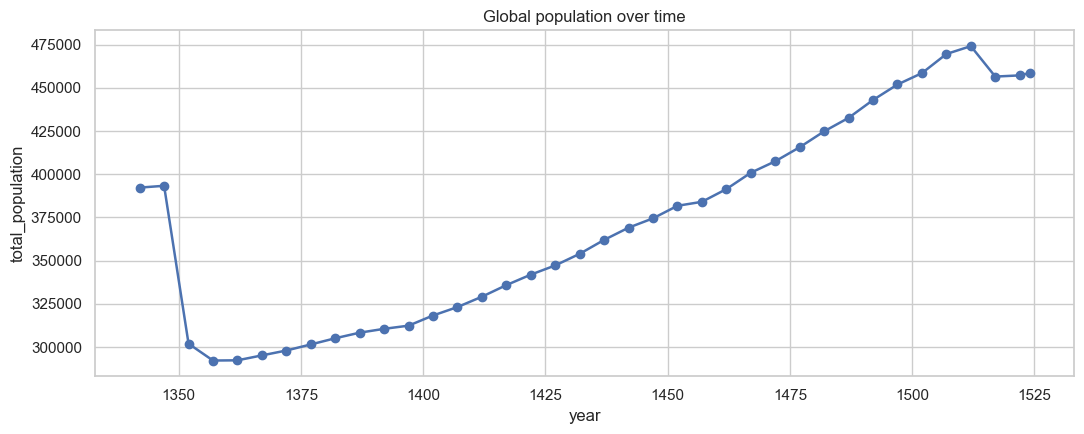

In [4]:
workbench.plot_population(population)


## Goods And Markets

In [5]:
goods = workbench.goods()
goods_global_ts = goods.global_time_series
market_scarcity = goods.scarcity
goods_imbalance = goods.imbalance
goods_imbalance_all = goods.goods_imbalance_all
market_flow_value = goods.flow_value
goods_global_ts, market_scarcity.head(TOP_N), market_flow_value.head(TOP_N)


(shape: (38, 12)
 ┌────────┬────────┬────────┬──────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
 │ date_s ┆ good_i ┆ good_l ┆ year ┆ supply ┆ deman ┆ stock ┆ mean_ ┆ media ┆ price ┆ price ┆ net   │
 │ ort    ┆ d      ┆ abel   ┆ ---  ┆ ---    ┆ d     ┆ pile  ┆ price ┆ n_pri ┆ _p10  ┆ _p90  ┆ ---   │
 │ ---    ┆ ---    ┆ ---    ┆ u16  ┆ f32    ┆ ---   ┆ ---   ┆ ---   ┆ ce    ┆ ---   ┆ ---   ┆ f32   │
 │ u32    ┆ str    ┆ str    ┆      ┆        ┆ f32   ┆ f32   ┆ f32   ┆ ---   ┆ f32   ┆ f32   ┆       │
 │        ┆        ┆        ┆      ┆        ┆       ┆       ┆       ┆ f32   ┆       ┆       ┆       │
 ╞════════╪════════╪════════╪══════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
 │ 134204 ┆ victua ┆ Victua ┆ 1342 ┆ 4088.8 ┆ 2868. ┆ 41134 ┆ 2.207 ┆ 2.014 ┆ 1.375 ┆ 2.940 ┆ 1220. │
 │ 01     ┆ ls     ┆ ls     ┆      ┆ 99902  ┆ 84765 ┆ .0546 ┆ 027   ┆ 96    ┆ 65    ┆ 63    ┆ 05224 │
 │        ┆        ┆        ┆      ┆        ┆ 6     ┆ 88    ┆    

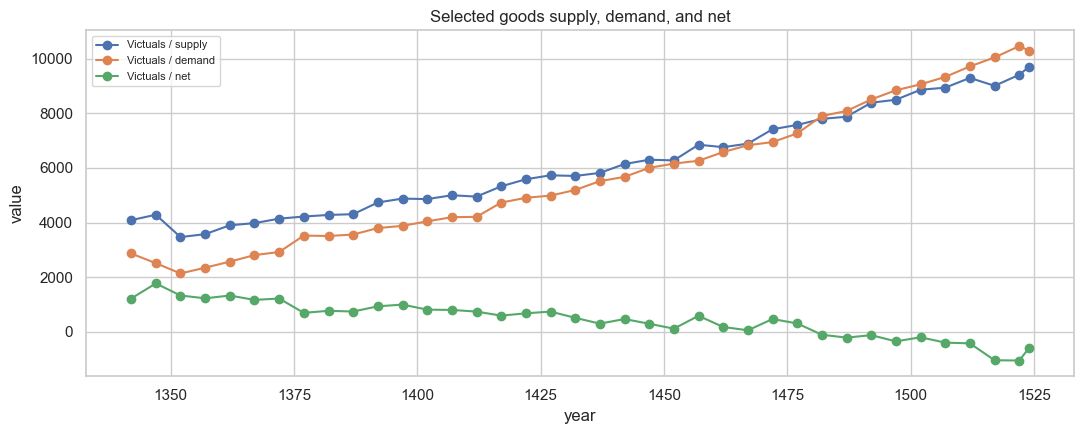

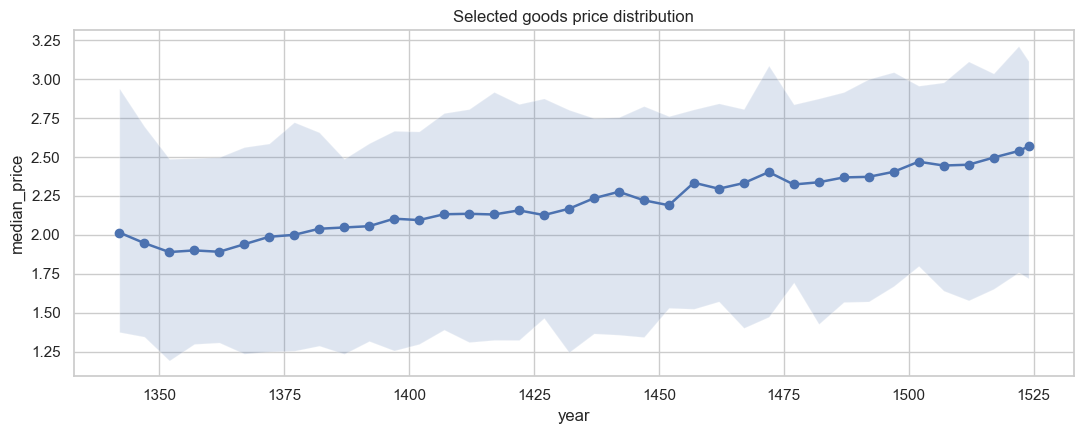

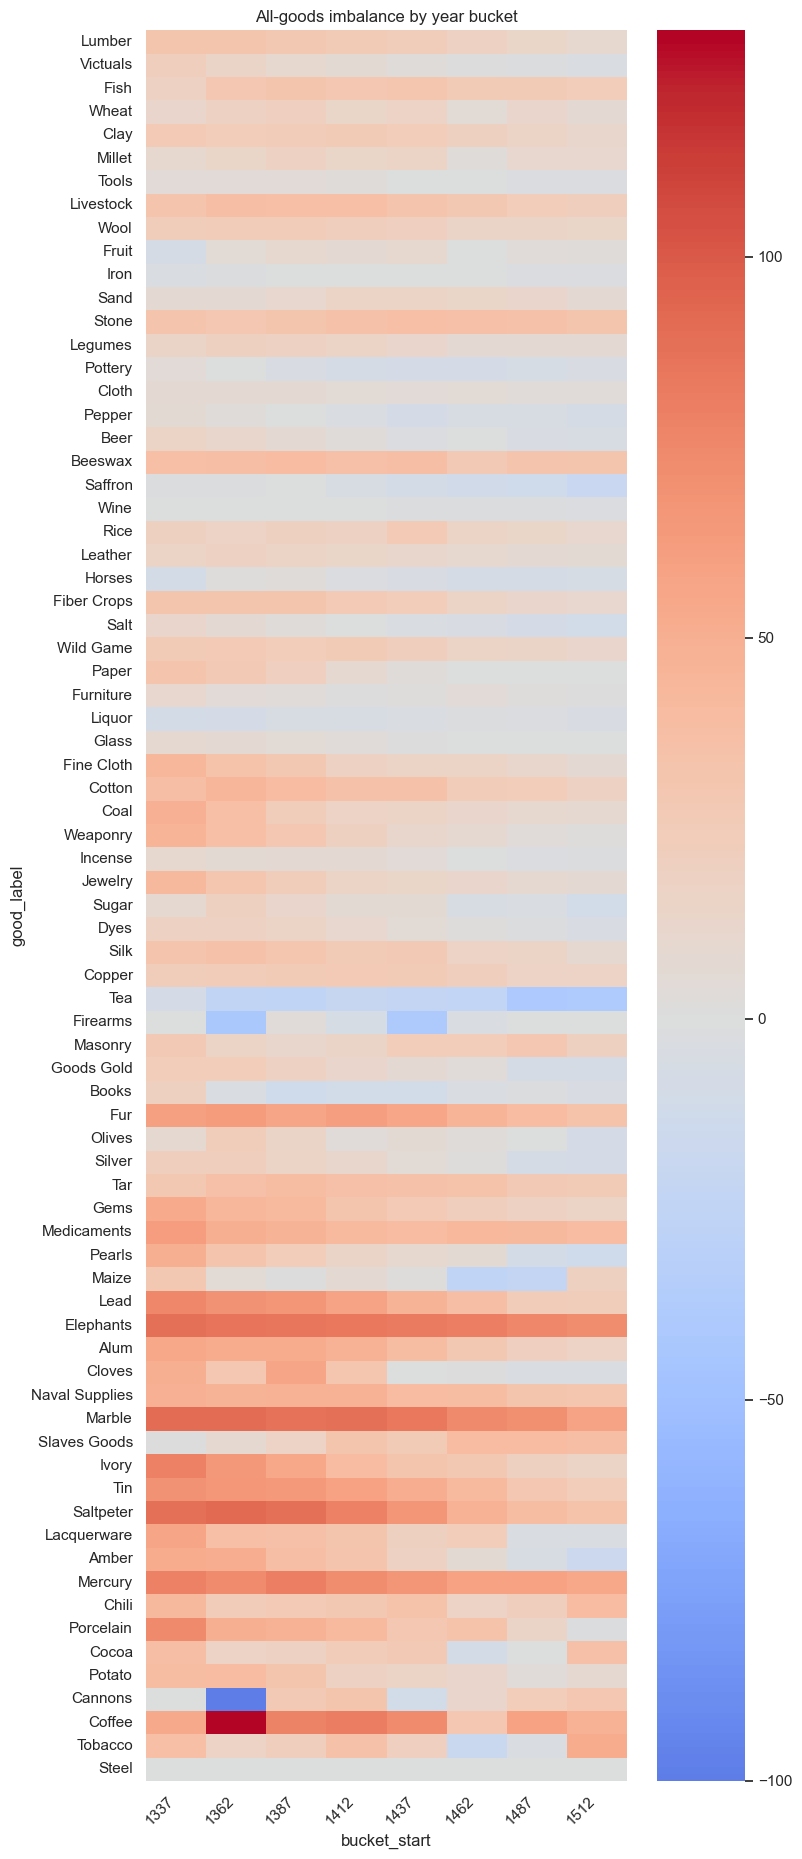

In [6]:
workbench.plot_goods(goods)


## Goods Source / Sink Flows

In [7]:
flows = workbench.flows()
source_breakdown = flows.source_breakdown
sink_breakdown = flows.sink_breakdown
source_ts = flows.source_time_series
sink_ts = flows.sink_time_series
good_consumption_latest = flows.good_consumption_latest
good_consumption_over_time = flows.good_consumption_over_time
source_breakdown, sink_breakdown, good_consumption_latest


(shape: (25, 3)
 ┌───────────────────┬────────────────┬────────────┐
 │ flow_table        ┆ market_label   ┆ amount     │
 │ ---               ┆ ---            ┆ ---        │
 │ str               ┆ str            ┆ f32        │
 ╞═══════════════════╪════════════════╪════════════╡
 │ production_method ┆ Prague         ┆ 390.529053 │
 │ production_method ┆ Paris          ┆ 370.965454 │
 │ production_method ┆ Delhi          ┆ 354.34256  │
 │ production_method ┆ Kyoto          ┆ 336.19339  │
 │ production_method ┆ Kataka         ┆ 328.422272 │
 │ production_method ┆ Genoa          ┆ 299.266388 │
 │ production_method ┆ Khambat        ┆ 289.781219 │
 │ production_method ┆ Pazhaverkadu   ┆ 241.082047 │
 │ production_method ┆ Nuremberg      ┆ 239.312271 │
 │ production_method ┆ Venice         ┆ 202.904556 │
 │ production_method ┆ Bruges         ┆ 193.919891 │
 │ production_method ┆ Varanasi       ┆ 188.641251 │
 │ production_method ┆ Constantinople ┆ 184.794754 │
 │ production_method ┆ Cologne

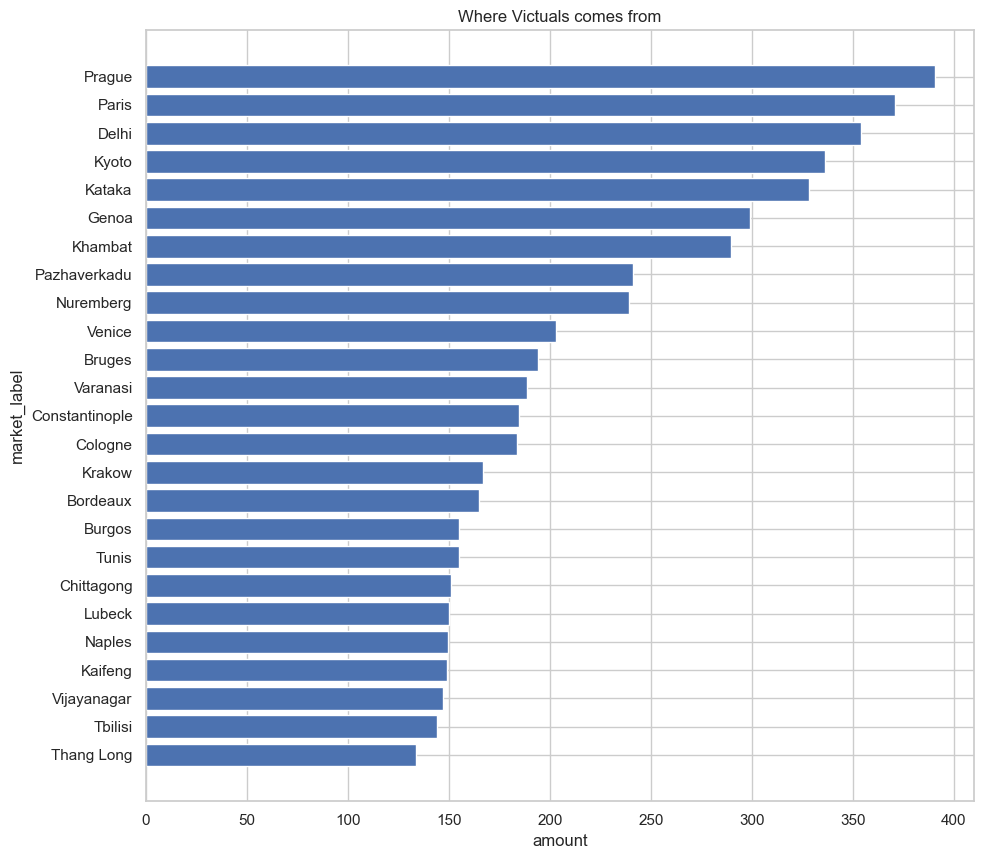

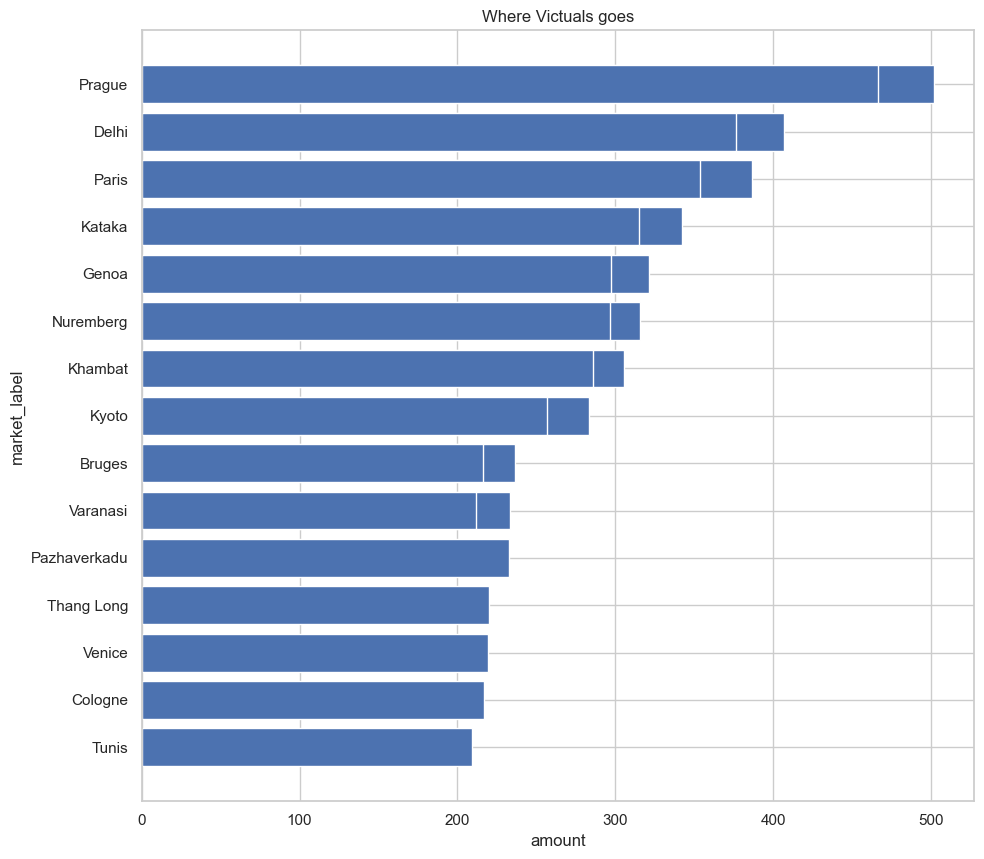

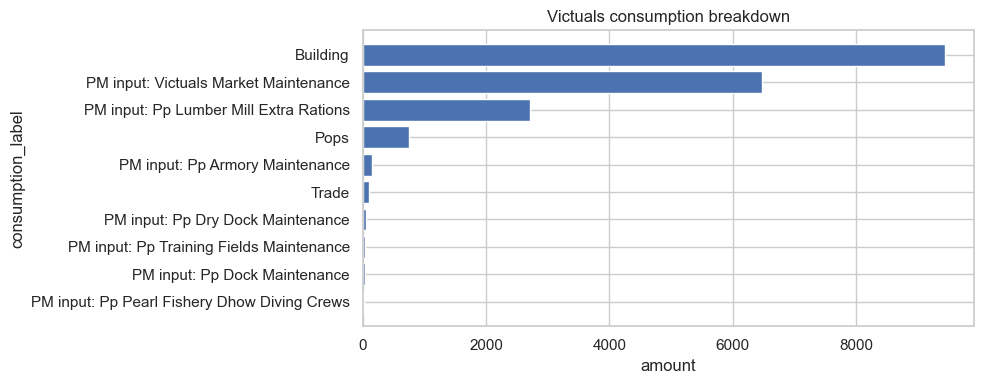

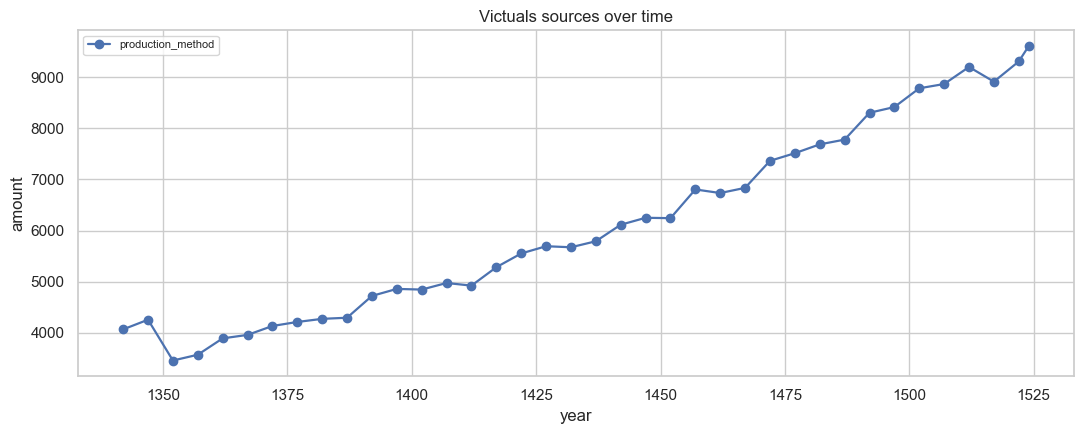

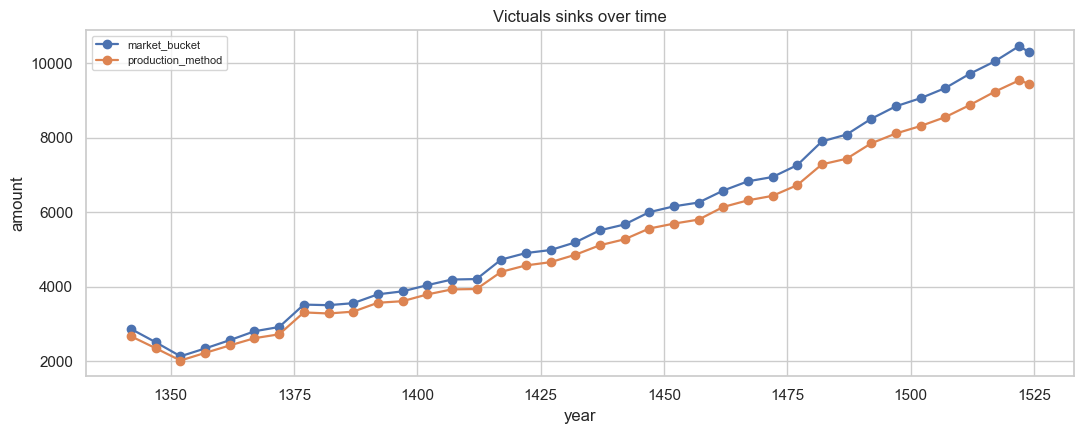

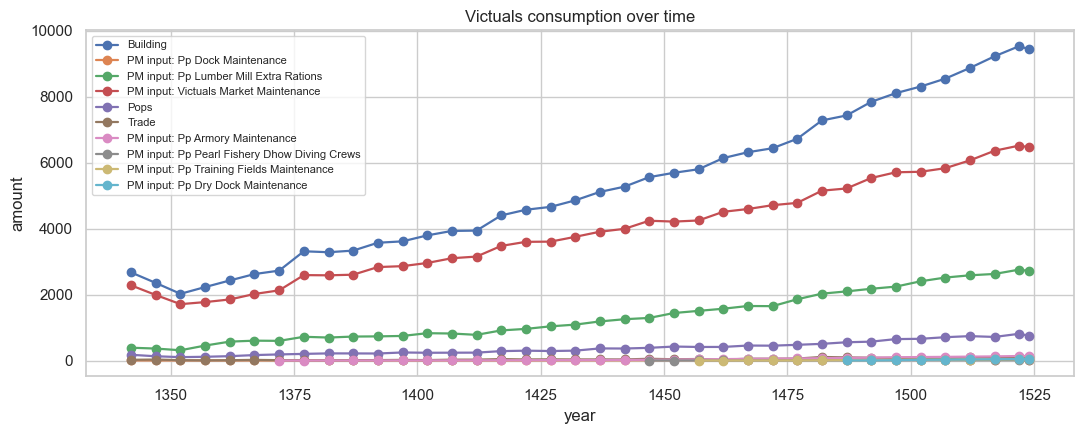

In [8]:
workbench.plot_flows(flows)


## Food Markets

In [9]:
food = workbench.food()
food_rank = food.rank
food_global = food.global_time_series
food_price_distribution = food.price_distribution
food_delta = food.delta
food_rank, food_delta, food_global


(shape: (25, 9)
 ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
 │ market_i ┆ market_l ┆ food     ┆ food_max ┆ food_bal ┆ populati ┆ capacity ┆ food_pri ┆ food_fil │
 │ d        ┆ abel     ┆ ---      ┆ ---      ┆ ance     ┆ on       ┆ ---      ┆ ce       ┆ l_ratio  │
 │ ---      ┆ ---      ┆ f32      ┆ f32      ┆ ---      ┆ ---      ┆ f32      ┆ ---      ┆ ---      │
 │ i64      ┆ str      ┆          ┆          ┆ f32      ┆ f32      ┆          ┆ f32      ┆ f32      │
 ╞══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
 │ 76       ┆ Jingzhao ┆ 0.0      ┆ 39718.58 ┆ 0.0      ┆ 1079.205 ┆ 7.37096  ┆ 0.12648  ┆ null     │
 │          ┆          ┆          ┆ 2031     ┆          ┆ 322      ┆          ┆          ┆          │
 │ 63       ┆ Urgench  ┆ 0.0      ┆ 6646.673 ┆ 0.0      ┆ 118.2409 ┆ 2.72647  ┆ 0.12957  ┆ null     │
 │          ┆          ┆          ┆ 828      ┆          ┆ 52      

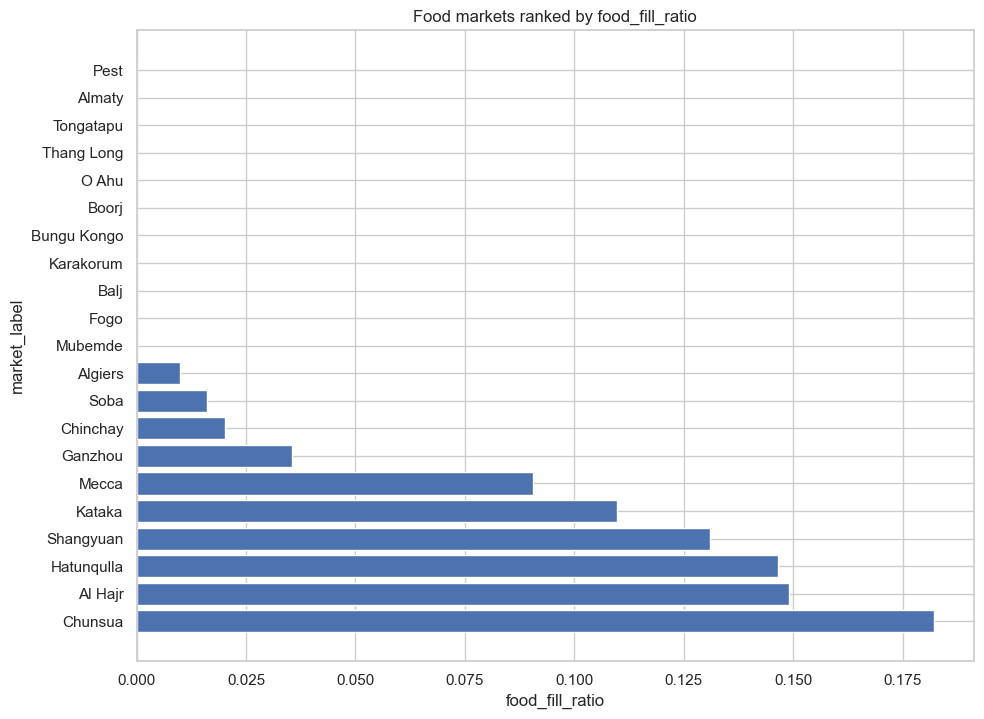

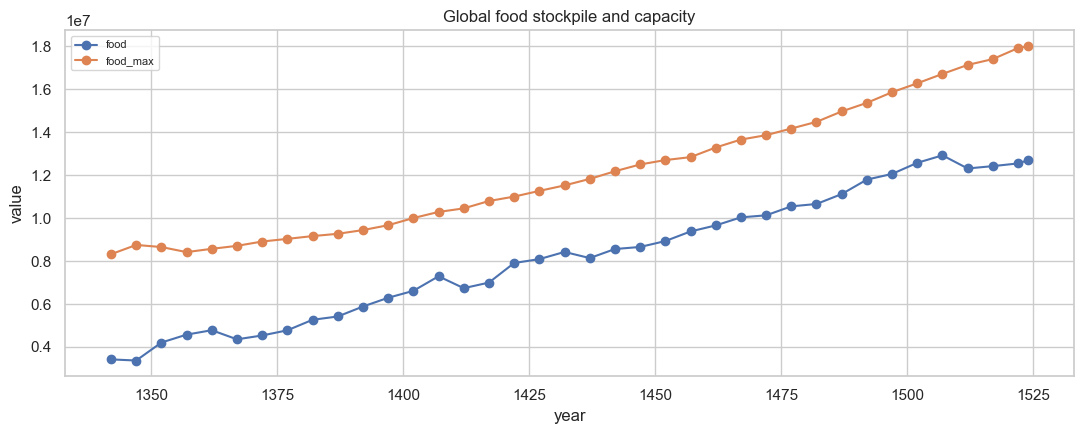

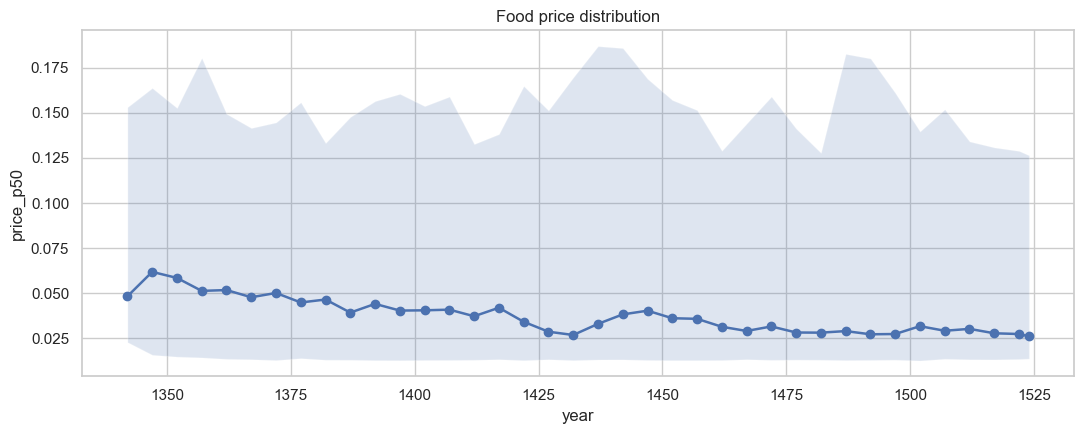

In [10]:
workbench.plot_food(food)


## Buildings And Production Methods

In [11]:
buildings = workbench.buildings()
building_latest = buildings.latest
building_ts = buildings.time_series
pm_adoption = buildings.pm_adoption
pm_preferences = buildings.pm_preferences
pm_regional_preferences_by_slot = buildings.pm_regional_preferences_by_slot
pm_slot_ts = buildings.pm_slot_time_series
pm_usage_by_slot_over_time = buildings.pm_usage_by_slot_over_time
pm_values = buildings.pm_values
building_latest, pm_regional_preferences_by_slot, pm_values.head(TOP_N)


(shape: (25, 3)
 ┌────────────────┬──────────────────────┬───────┐
 │ building_label ┆ region_label         ┆ level │
 │ ---            ┆ ---                  ┆ ---   │
 │ str            ┆ str                  ┆ f32   │
 ╞════════════════╪══════════════════════╪═══════╡
 │ Cookery        ┆ North German Region  ┆ 201.0 │
 │ Cookery        ┆ Indochina Region     ┆ 188.0 │
 │ Cookery        ┆ France Region        ┆ 164.0 │
 │ Cookery        ┆ Italy Region         ┆ 159.0 │
 │ Cookery        ┆ South German Region  ┆ 139.0 │
 │ Cookery        ┆ Deccan Region        ┆ 132.0 │
 │ Cookery        ┆ Iberia Region        ┆ 128.0 │
 │ Cookery        ┆ Japan Region         ┆ 127.0 │
 │ Cookery        ┆ Mesoamerica Region   ┆ 125.0 │
 │ Cookery        ┆ South China Region   ┆ 106.0 │
 │ Cookery        ┆ Indonesia Region     ┆ 106.0 │
 │ Cookery        ┆ Baltic Region        ┆ 93.0  │
 │ Cookery        ┆ Bengal Region        ┆ 91.0  │
 │ Cookery        ┆ Balkan Region        ┆ 85.0  │
 │ Cookery     

In [12]:
workbench.plot_building_slot(buildings, 0)


In [13]:
workbench.plot_building_slot(buildings, 1)


In [14]:
workbench.plot_building_slot(buildings, 2)
